# The Internet and Dating

Cisco was founded by Sandy Lerner and Leonard Bosak because of love and the need to connect.

In 1984, Sandy and Leonard were dating while working in two separate buildings at Stanford University. They figured out how to connect their computers together over long distances so that they could communicate throughout the day. This gave birth to computer networks and the founding of Cisco.

In this project, we will investigate the influence of the Internet on how couples meet. Along the way, you will learn three Pro Tips for creating effective multi-line graphs.

### Loading the Data
The file `how-couples-met.csv` contains survey data on the ways couples met from the 1960s to the 2010s.


In [20]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns


In [21]:
df = pd.read_csv('how-couples-met.csv')
df 

,decade,college,at work,through friends,through family,online,restaurant,neighbors
0,1960.0,12.2,18.2,45.9,30.4,0.0,21.5,11.6
1,1970.0,16.4,23.9,48.9,28.6,0.0,25.0,8.9
2,1980.0,10.2,32.4,36.6,20.2,0.3,28.3,8.0
3,1990.0,10.5,30.7,35.9,18.5,3.2,26.2,7.7
4,2000.0,10.6,20.3,38.1,15.2,22.6,18.5,8.8
5,2010.0,6.7,15.5,28.9,10.0,42.2,14.0,4.3


The data captures seven of the common ways couples met, including at college or work, through friends or family, online, at a restaurant, or as neighbors.

We see the percentage of couples who reported that they met by each method, for each decade. In the 1960s, most couples met through friends or family. By the 2010s, meeting through family had dropped to only 10% of couples.

### Visualizing time series

A time series is a sequence of data points ordered by time. A great way to visualize a time series is to use a line graph. Let's create the plot directly from pandas. Run the code below.

In [22]:
df = df.set_index('decade')
df 

,college,at work,through friends,through family,online,restaurant,neighbors
decade,,,,,,,
1960.0,12.2,18.2,45.9,30.4,0.0,21.5,11.6
1970.0,16.4,23.9,48.9,28.6,0.0,25.0,8.9
1980.0,10.2,32.4,36.6,20.2,0.3,28.3,8.0
1990.0,10.5,30.7,35.9,18.5,3.2,26.2,7.7
2000.0,10.6,20.3,38.1,15.2,22.6,18.5,8.8
2010.0,6.7,15.5,28.9,10.0,42.2,14.0,4.3


<Axes: xlabel='decade'>

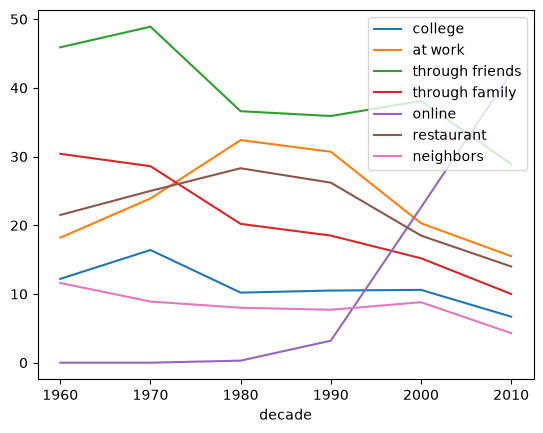

In [23]:
df.plot()


The purple line, representing meeting online, shows a dramatic rise from 3% in the 1990s to 42% in the 2010s, becoming the dominant method that couples meet.

### Visual storytelling

The big story in this graph is that meeting online has rapidly become the most popular way for couples to meet. How can we make this story stand out?

Let's create a new line graph, this time drawing attention to the line for meeting online.

We will start by making the `online` line thicker and red (`C3`). We will also reduce the transparency of the other lines, making them dimmer.

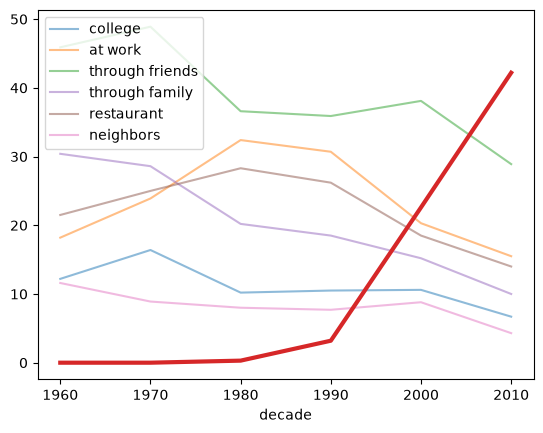

In [24]:
focus_column = 'online'
focus_color = 'C3' #red
back_columns = [
    'college', 'at work', 'through friends',
    'through family', 'restaurant', 'neighbors'
]
back_colors = ['C0', 'C1', 'C2',  'C4', 'C5', 'C6']
df.plot(y=back_columns, color=back_colors, alpha=0.5)
plt.plot(df.index, df[focus_column], color=focus_color, linewidth=3)
plt.show()

Our graph now emphasizes that meeting online has become the most popular way for couples to meet. The story is more 


In [25]:
def add_end_labels(df, x, column_names, alpha):
    for column_name in column_names:
        y = df[column_name].iloc[-1]
        offset_spacing = "  "
        label = offset_spacing + column_name
        plt.text(x, y, label, va="center", alpha=alpha)



Let's label the lines with our helper function! Remember that the storytelling goal here is for the graph to emphasize that meeting online has become the most common way for couples to meet.


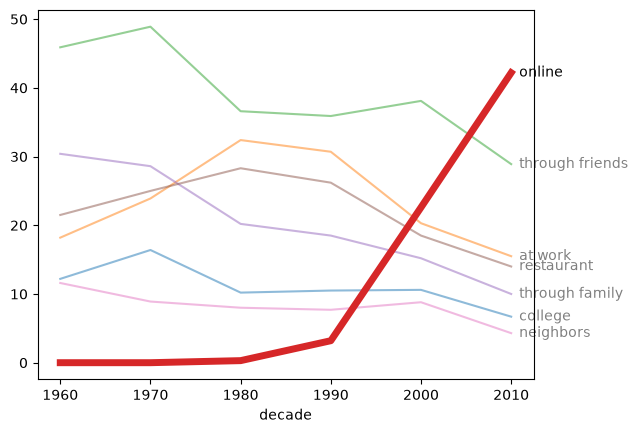

In [26]:
df.plot(y=back_columns, color=back_colors, alpha=0.5)
plt.plot(df.index, df[focus_column], color=focus_color, linewidth=5)
plt.legend().set_visible(False)
add_end_labels(df, 2010, back_columns, alpha=0.5)
add_end_labels(df, 2010, [focus_column], alpha=1)


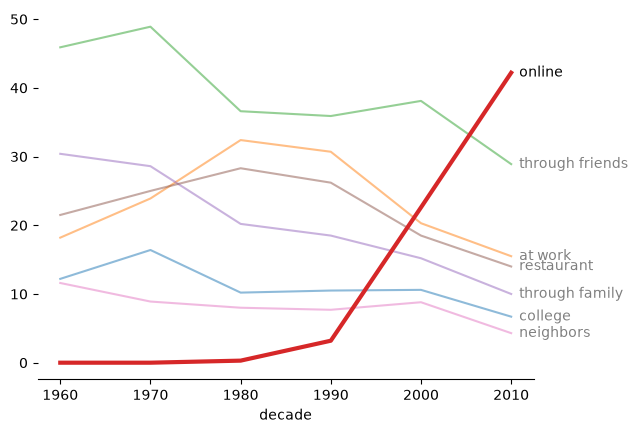

In [27]:
df.plot(y=back_columns, color=back_colors, alpha=0.5)
plt.plot(df.index, df[focus_column], color=focus_color, linewidth=3)
plt.legend().set_visible(False)
add_end_labels(df, 2010, back_columns, alpha=0.5)
add_end_labels(df, 2010, [focus_column], alpha=1)

ax = plt.gca()
ax.spines[['left', 'top', 'right']].set_visible(False)


Next let's replace the floating tick marks on the y axis with horizontal grid lines. We can also fade the gridlines by reducing the alpha to 50%.

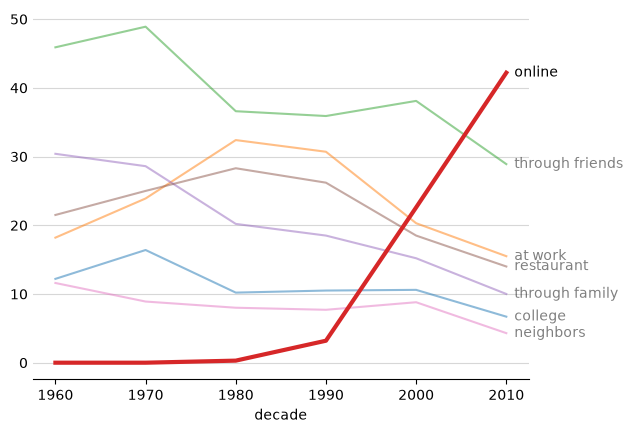

In [28]:
df.plot(y=back_columns, color=back_colors, alpha=0.5)
plt.plot(df.index, df[focus_column], color=focus_color, linewidth=3)
plt.legend().set_visible(False)
add_end_labels(df, 2010, back_columns, alpha=0.5)
add_end_labels(df, 2010, [focus_column], alpha=1)

ax = plt.gca()
ax.spines[['left', 'top', 'right']].set_visible(False)
ax.tick_params(axis='y', length=0)
plt.grid(axis='y', alpha=0.5)

In [29]:
def clean_axes( ):
    ax = plt.gca()
    ax.spines[['left', 'top', 'right']].set_visible(False)
    ax.tick_params(axis='y', length=0)
    plt.grid(axis='y', alpha=0.5)

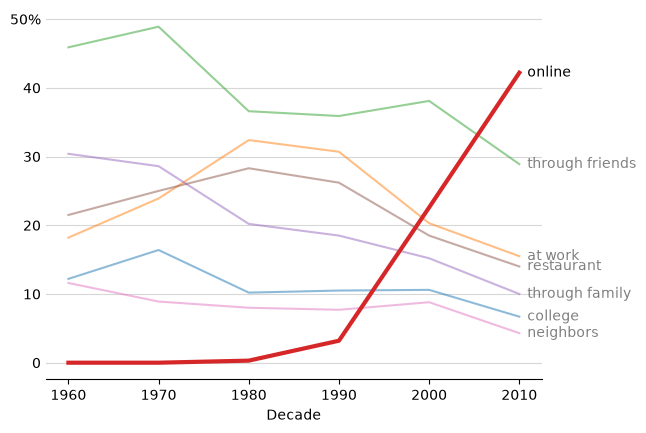

In [30]:
df.plot(y=back_columns, color=back_colors, alpha=0.5)
plt.plot(df.index, df[focus_column], color=focus_color, linewidth=3)
plt.legend().set_visible(False)
add_end_labels(df, 2010, back_columns, alpha=0.5)
add_end_labels(df, 2010, [focus_column], alpha=1)
clean_axes()

y_ticks = [0, 10, 20, 30, 40, 50]
y_tick_labels = ['0', '10', '20', '30', '40', '50%']
plt.yticks(y_ticks, y_tick_labels)
plt.xlabel('Decade')
plt.show()

In [31]:
def add_axes_labels( ):
    y_ticks = [0, 10, 20, 30, 40, 50]
    y_tick_labels = ['0', '10', '20', '30', '40', '50%']
    plt.yticks(y_ticks, y_tick_labels)
    plt.xlabel('Decade')



## Project extensions

### Project Extension 1: Horizontal Bar Plot for a Specific Decade

Let's create a horizontal bar plot for the 2010 decade to visualize the proportion of couples who met through each method. This will give us a clear overview of the most popular meeting methods in recent times.

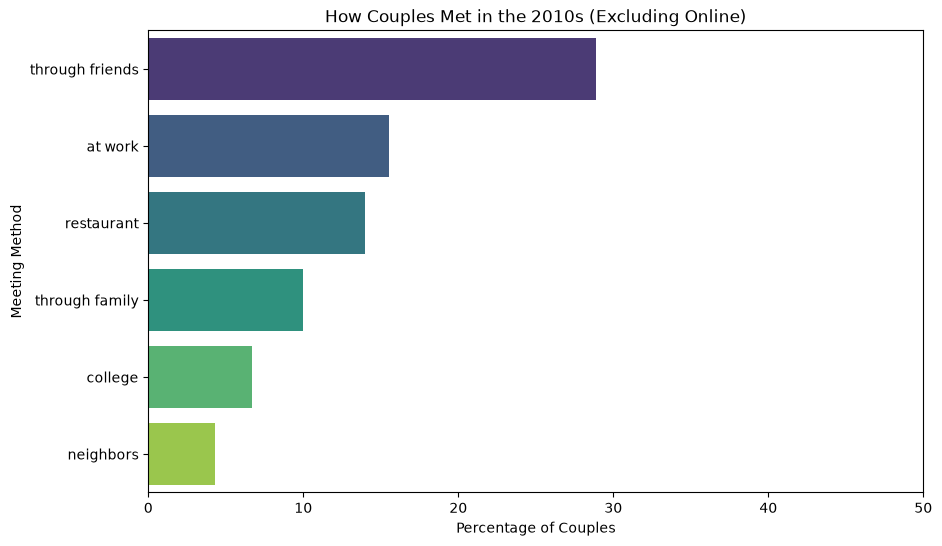

In [32]:


decade_2010 = df.loc[2010.0].drop(['online']).sort_values(ascending=False)


fig = plt.figure(figsize=(10, 6))
sns.barplot(x=decade_2010.values, y=decade_2010.index, hue=decade_2010.index, palette='viridis', legend=False)
plt.title('How Couples Met in the 2010s (Excluding Online)')
plt.xlabel('Percentage of Couples')
plt.ylabel('Meeting Method')
plt.xlim(0, 50)
plt.show()

This bar plot for the 2010s shows that 'through friends' was still a significant way couples met, followed by 'at work' and 'restaurant'. However, it's important to remember that this specific plot *excludes* the 'online' category, which we know from the line graph was the dominant method by 2010. The exclusion was made to better visualize the relative proportions of other traditional meeting methods for this specific exercise.

### Project Extension 2: Subplots of Horizontal Bar Plots for Two Different Decades

Now, let's compare two decades to see how meeting methods have changed over time. We'll use subplots to show the distribution of meeting methods for the 1960s and the 2010s side-by-side, including the 'online' category this time to highlight its growth.

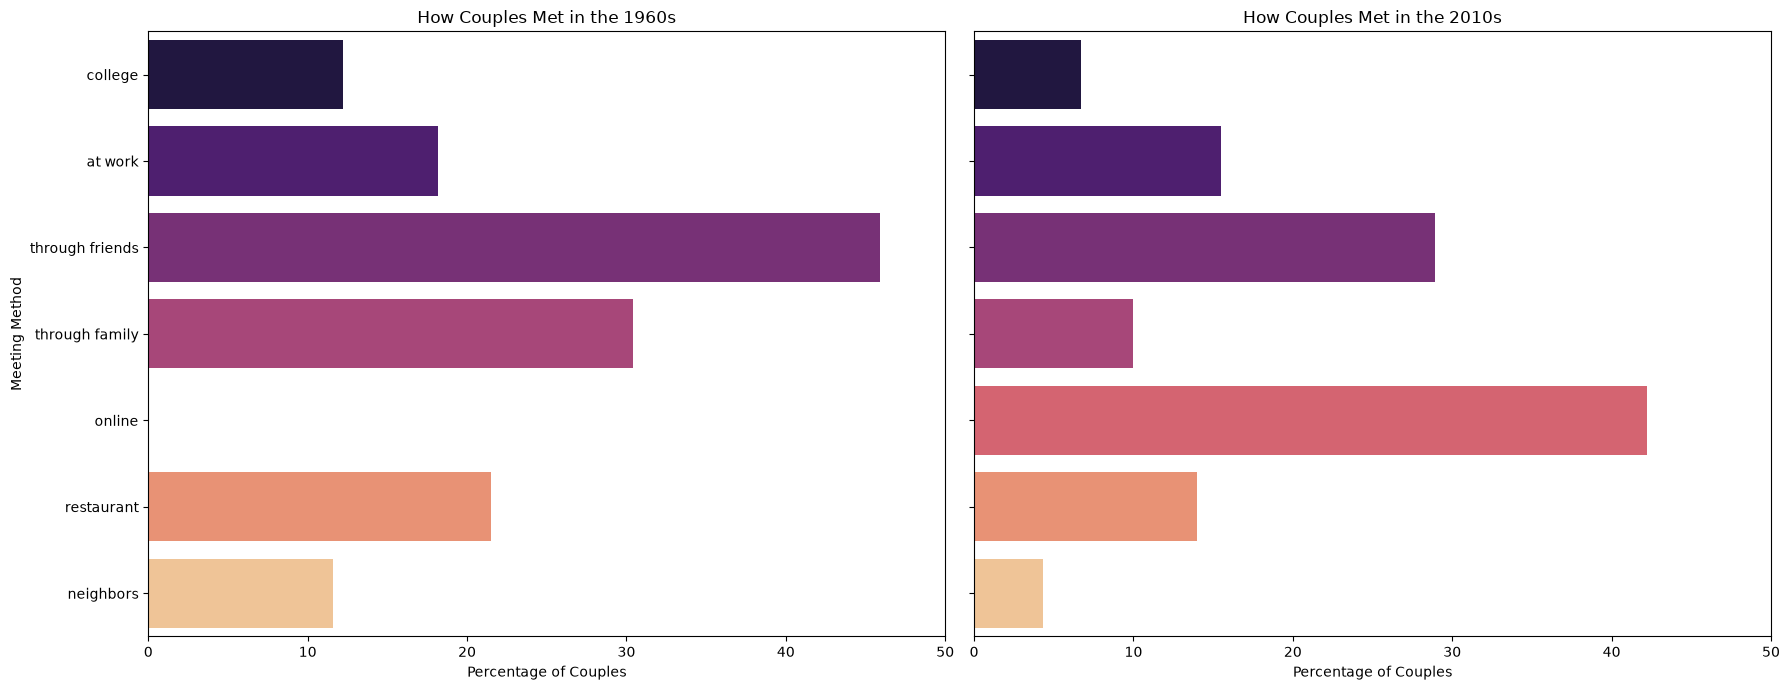

In [33]:

decade_1960 = df.loc[1960.0]
decade_2010 = df.loc[2010.0]


fig, axes = plt.subplots(1, 2, figsize=(18, 7), sharey=True)


sns.barplot(x=decade_1960.values, y=decade_1960.index, hue=decade_1960.index, ax=axes[0], palette='magma', legend=False)
axes[0].set_title('How Couples Met in the 1960s')
axes[0].set_xlabel('Percentage of Couples')
axes[0].set_ylabel('Meeting Method')
axes[0].set_xlim(0, 50) 


sns.barplot(x=decade_2010.values, y=decade_2010.index, hue=decade_2010.index, ax=axes[1], palette='magma', legend=False)
axes[1].set_title('How Couples Met in the 2010s')
axes[1].set_xlabel('Percentage of Couples')
axes[1].set_xlim(0, 50) 


plt.tight_layout()
plt.show()

These subplots clearly demonstrate the dramatic shift in how couples meet. In the 1960s, 'through friends' and 'through family' were the predominant methods, followed by 'restaurant' and 'at work'. The 'online' category was non-existent. 

By contrast, the 2010s show a complete transformation, with 'online' surging to become the dominant method by a large margin. Traditional methods like 'through friends' and 'through family' have significantly decreased in proportion, although they still remain relevant. This visualization powerfully illustrates the profound impact of the internet on social connections and relationship formation over fifty years.

### Conclusion

This project investigated the profound influence of the internet on how couples meet, utilizing survey data from the 1960s to the 2010s. We began by loading and preparing the data, setting the 'decade' as the index for time series analysis.

The initial line graph revealed a compelling narrative: the dramatic rise of 'online' as a primary method for couples to meet. What started as negligible in the 1990s surged to become the dominant method by the 2010s, surpassing all other traditional avenues.

To enhance the visual storytelling, we applied three Pro Tips for creating effective multi-line graphs:

1.  **Direct Labeling:** We replaced the cluttered legend with direct labels on each line, improving readability and focus.
2.  **Clean Axes:** We removed distracting spines and replaced tick marks with faded horizontal grid lines, creating a cleaner and more professional aesthetic.
3.  **Minimized Rotated Text:** We avoided vertical y-axis labels by integrating the percentage unit directly into the y-tick labels, enhancing readability.

The project extensions further solidified these findings. A horizontal bar plot for the 2010s, even when excluding 'online' to highlight other methods, demonstrated the relative proportions of traditional meeting places. More strikingly, the comparative bar plots for the 1960s and 2010s starkly illustrated the generational shift, confirming that the digital age has fundamentally reshaped how romantic relationships begin.

**Overall Takeaway:** The analysis unequivocally shows that the internet has revolutionized the landscape of dating and relationship formation. While traditional methods of meeting still exist, the digital sphere has become an indispensable and, indeed, the most prominent platform for couples to connect in the 21st century. This transformation reflects broader societal changes in how individuals interact, driven by technological advancements and increased connectivity.